## MS Disease Progression: A Network Delay Perspective

This notebook models the progressive neural network changes associated with Multiple Sclerosis (MS) 
using the Wilson-Cowan metapopulation DDE framework (Conti & Van Gorder, 2019), extended with 
heterogeneous delay structure (Atay & Hutt, 2006).

MS is a demyelinating disease of the central nervous system characterised by progressive degradation 
of the myelin sheath surrounding axons. This has direct consequences for neural signal transmission:

- **Demyelination** reduces and destabilises axonal conduction velocity
- **Axonal loss** in advanced stages permanently disrupts network connectivity

We model these effects through three mechanisms already present in our delay framework:
1. Reduced mean conduction velocity (vm)
2. Increased heterogeneity in conduction velocities (lower shape parameter p)
3. Random edge removal to simulate axonal loss (stage 3 only)

We track how these progressive changes affect oscillatory dynamics across four network topologies, 
asking: does network architecture determine vulnerability to MS-related dynamic disruption?

### References
- Compston & Coles (2008) - Multiple sclerosis. Lancet.
- Waxman (2006) - Ions, energy and axonal injury. Trends in Neurosciences.
- Bjartmar & Trapp (2001) - Axonal and neuronal degeneration in MS. Current Opinion in Neurology.
- Atay & Hutt (2006) - Neural fields with distributed transmission speeds. SIAM Journal.
- Conti & Van Gorder (2019) - Network structure and time delay in Wilson-Cowan model. JTB.

In [25]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

sys.path.append(os.path.abspath(".."))

from src.metapopulation import Metapopulation
from src.delays import heterogeneous_delay_matrix
from src.ms_progression import remove_edges, get_stage_params, MS_STAGES, REMOVAL_RATES

CONFIG = os.path.join(os.path.dirname(os.path.abspath("__file__")), "distance_delays.yaml")
TOPOLOGIES = ['line', 'full', 'ring', 'lattice']
N = 16
SEED = 42

In [26]:
df_stages = pd.DataFrame([
    {
        'Stage': stage,
        'Description': params['description'],
        'vm (m/s)': params['vm'],
        'p (shape)': params['p'],
        'Axonal Loss': 'Yes' if stage == 3 else 'No'
    }
    for stage, params in MS_STAGES.items()
])
display(df_stages)

print("\nEdge removal rates for stage 3:")
df_removal = pd.DataFrame([
    {'Topology': t, 'Removal Rate': f"{int(r*100)}%", 'Edges removed (N=16)': 'N/A - too sparse' if r==0 else 'random'}
    for t, r in REMOVAL_RATES.items()
])
display(df_removal)

,Stage,Description,vm (m/s),p (shape),Axonal Loss
0,0,Healthy baseline,6.0,10.00,No
1,1,Early progressive MS: focal demyelination,4.0,4.50,No
2,2,Moderate progressive MS: widespread demyelination,2.0,2.50,No
3,3,Severe progressive MS: axonal loss,1.5,2.01,Yes



Edge removal rates for stage 3:


,Topology,Removal Rate,Edges removed (N=16)
0,line,0%,N/A - too sparse
1,full,30%,random
2,ring,20%,random
3,lattice,25%,random


In [27]:
def run_stage(topology, stage, seed=SEED):
    params = get_stage_params(stage)
    
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': topology, 'N': N})
    
    if stage == 3:
        n_removed = remove_edges(m.network, topology, seed=seed)
        print(f"  {topology}: removed {n_removed} edges")
    
    m.create_delay_matrix(
        mode='heterogeneous',
        vm=params['vm'],
        p=params['p'],
        seed=seed
    )
    m.initialise_model(params={
        'tau_1': params['tau_1'],
        'tau_2': params['tau_2']
    })
    m.run_simulation()
    return m


def get_synchrony(trajectories, t_array, t_start=20):
    mask = t_array >= t_start
    E = trajectories[0][:, mask]
    return float(np.mean(np.var(E, axis=0)))


def get_frequency(trajectories, t_array, dt=0.1, t_start=20):
    mask = t_array >= t_start
    E = trajectories[0][:, mask]
    freqs = np.fft.rfftfreq(E.shape[1], d=dt)
    fft_power = np.abs(np.fft.rfft(E, axis=1))
    fft_power[:, 0] = 0
    fft_mean = np.mean(fft_power, axis=0)
    return float(freqs[np.argmax(fft_mean)])


def plot_stage(results, stage, t_start=25):
    """Plot trajectories and delay matrices for all topologies at a given stage."""
    fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(18, 8))
    fig.suptitle(f"Stage {stage}: {MS_STAGES[stage]['description']}")

    # Global colorbar range across all topologies for this stage
    all_delays = [results[(topology, stage)].model.params['rho'] for topology in TOPOLOGIES]
    vmin = min(D.min() for D in all_delays)
    vmax = max(D.max() for D in all_delays)
    
    for i, topology in enumerate(TOPOLOGIES):
        m = results[(topology, stage)]
        t = m.model.time_array
        mask = t >= t_start
        
        # Trajectory
        axes[0, i].plot(t[mask], m.model.trajectories[0][:, mask].T, 
                       color='blue', alpha=0.5, linewidth=0.8)
        axes[0, i].plot(t[mask], m.model.trajectories[1][:, mask].T, 
                       color='black', alpha=0.5, linewidth=0.8)
        axes[0, i].set_title(topology)
        axes[0, i].set_ylim(0, 1)
        axes[0, i].set_xlabel("Time (ms)")
        if i == 0:
            axes[0, i].set_ylabel("Activity")
        
        # Delay matrix
        D = m.model.params['rho']
        im = axes[1, i].imshow(D, cmap='viridis')
        axes[1, i].set_title(f"{topology} delay matrix")
        axes[1, i].set_xlabel("Node")
        axes[1, i].set_ylabel("Node")
        plt.colorbar(im, ax=axes[1, i])
    
    plt.tight_layout()
    plt.savefig(f"kavya_figures/ms_stage_{stage}.png", dpi=150)
    plt.show()


def get_metrics_df(results, stage):
    """Return synchrony and frequency metrics as a dataframe."""
    rows = []
    for topology in TOPOLOGIES:
        m = results[(topology, stage)]
        rows.append({
            'Topology': topology,
            'Stage': stage,
            'Description': MS_STAGES[stage]['description'],
            'Synchrony': get_synchrony(m.model.trajectories, m.model.time_array),
            'Frequency (Hz)': get_frequency(m.model.trajectories, m.model.time_array)
        })
    return pd.DataFrame(rows)

## Stage 0: Healthy Baseline

In the healthy brain, myelin sheaths are intact and conduction velocities are relatively 
uniform across axon tracts. We model this with:
- vm = 6.0 m/s (mode of Gamma distribution, within Atay & Hutt's reported 5-12 m/s range)
- p = 10.0 (narrow distribution, uniform myelination)
- Full connectivity

This establishes the baseline oscillatory dynamics against which all MS stages are compared.

In [28]:
results = {}

for topology in TOPOLOGIES:
    print(f"  {topology}...")
    results[(topology, 0)] = run_stage(topology, 0)

print("Done.")

  line...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[0.        , 0.14090648, 0.24604938, 0.94122009, 0.5958522 ,
        0.78006984, 0.71052402, 1.06346116, 1.07197561, 1.24319896,
        1.18453661, 1.81254499, 1.28684753, 2.32276689, 1.83921238,
        2.04405627],
       [0.14090648, 0.        , 0.08346679, 0.36765146, 0.38425131,
        0.64400485, 1.02414752, 0.73973183, 1.62454   , 1.55005995,
        1.34542354, 1.18698483, 1.38250428, 1.69911879, 3.35796058,
        2.53723419],
       [0.24604938, 0.08346679, 0.        , 0.16975621, 0.41569417,
        0.84560163, 0.58930023, 0.62236222, 1.04378473, 0.83418607,
        1.92984222, 1.90664195, 1.48275813, 1.96470593, 1.53255697,
        1.74769993],
       [0.94122009, 0.36765146, 0.16975621, 0.        , 0.17479966,
        0.46838726, 0.54351439, 0.53382058, 0.63096677, 1.07023063,
        1.97653155, 1.96404551, 1.23134181, 1.75686484,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  full...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[0.        , 0.14090648, 0.12302469, 0.31374003, 0.14896305,
        0.15601397, 0.11842067, 0.15192302, 0.13399695, 0.13813322,
        0.11845366, 0.16477682, 0.10723729, 0.17867438, 0.13137231,
        0.13627042],
       [0.14090648, 0.        , 0.08346679, 0.18382573, 0.12808377,
        0.16100121, 0.2048295 , 0.12328864, 0.23207714, 0.19375749,
        0.1494915 , 0.11869848, 0.12568221, 0.14159323, 0.25830466,
        0.18123101],
       [0.12302469, 0.08346679, 0.        , 0.16975621, 0.20784708,
        0.28186721, 0.14732506, 0.12447244, 0.17396412, 0.11916944,
        0.24123028, 0.21184911, 0.14827581, 0.17860963, 0.12771308,
        0.13443846],
       [0.31374003, 0.18382573, 0.16975621, 0.        , 0.17479966,
        0.23419363, 0.18117146, 0.13345515, 0.12619335, 0.17837177,
        0.2823616

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  ring...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[0.        , 0.14090648, 0.12302469, 0.31374003, 0.2979261 ,
        0.31202793, 0.23684134, 0.45576907, 0.40199086, 0.41439965,
        0.23690732, 0.32955363, 0.21447459, 0.17867438, 0.13137231,
        0.13627042],
       [0.14090648, 0.        , 0.08346679, 0.18382573, 0.12808377,
        0.32200243, 0.40965901, 0.24657728, 0.69623143, 0.58127248,
        0.44847451, 0.23739697, 0.25136441, 0.28318647, 0.25830466,
        0.18123101],
       [0.12302469, 0.08346679, 0.        , 0.16975621, 0.20784708,
        0.28186721, 0.29465011, 0.24894489, 0.34792824, 0.35750831,
        0.72369083, 0.63554732, 0.29655163, 0.35721926, 0.25542616,
        0.13443846],
       [0.31374003, 0.18382573, 0.16975621, 0.        , 0.17479966,
        0.23419363, 0.18117146, 0.26691029, 0.25238671, 0.35674354,
        0.8470849

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  lattice...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[0.        , 0.14090648, 0.24604938, 0.94122009, 0.14896305,
        0.31202793, 0.35526201, 0.60769209, 0.2679939 , 0.41439965,
        0.47381464, 0.82388409, 0.32171188, 0.7146975 , 0.65686156,
        0.81762251],
       [0.14090648, 0.        , 0.08346679, 0.36765146, 0.25616754,
        0.16100121, 0.40965901, 0.36986592, 0.69623143, 0.38751499,
        0.44847451, 0.47479393, 0.50272883, 0.4247797 , 1.03321864,
        0.90615507],
       [0.24604938, 0.08346679, 0.        , 0.16975621, 0.62354125,
        0.56373442, 0.14732506, 0.24894489, 0.69585649, 0.35750831,
        0.48246055, 0.63554732, 0.74137907, 0.71443852, 0.38313924,
        0.53775382],
       [0.94122009, 0.36765146, 0.16975621, 0.        , 0.69919864,
        0.7025809 , 0.36234293, 0.13345515, 0.63096677, 0.71348709,
        0.8470

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Done.


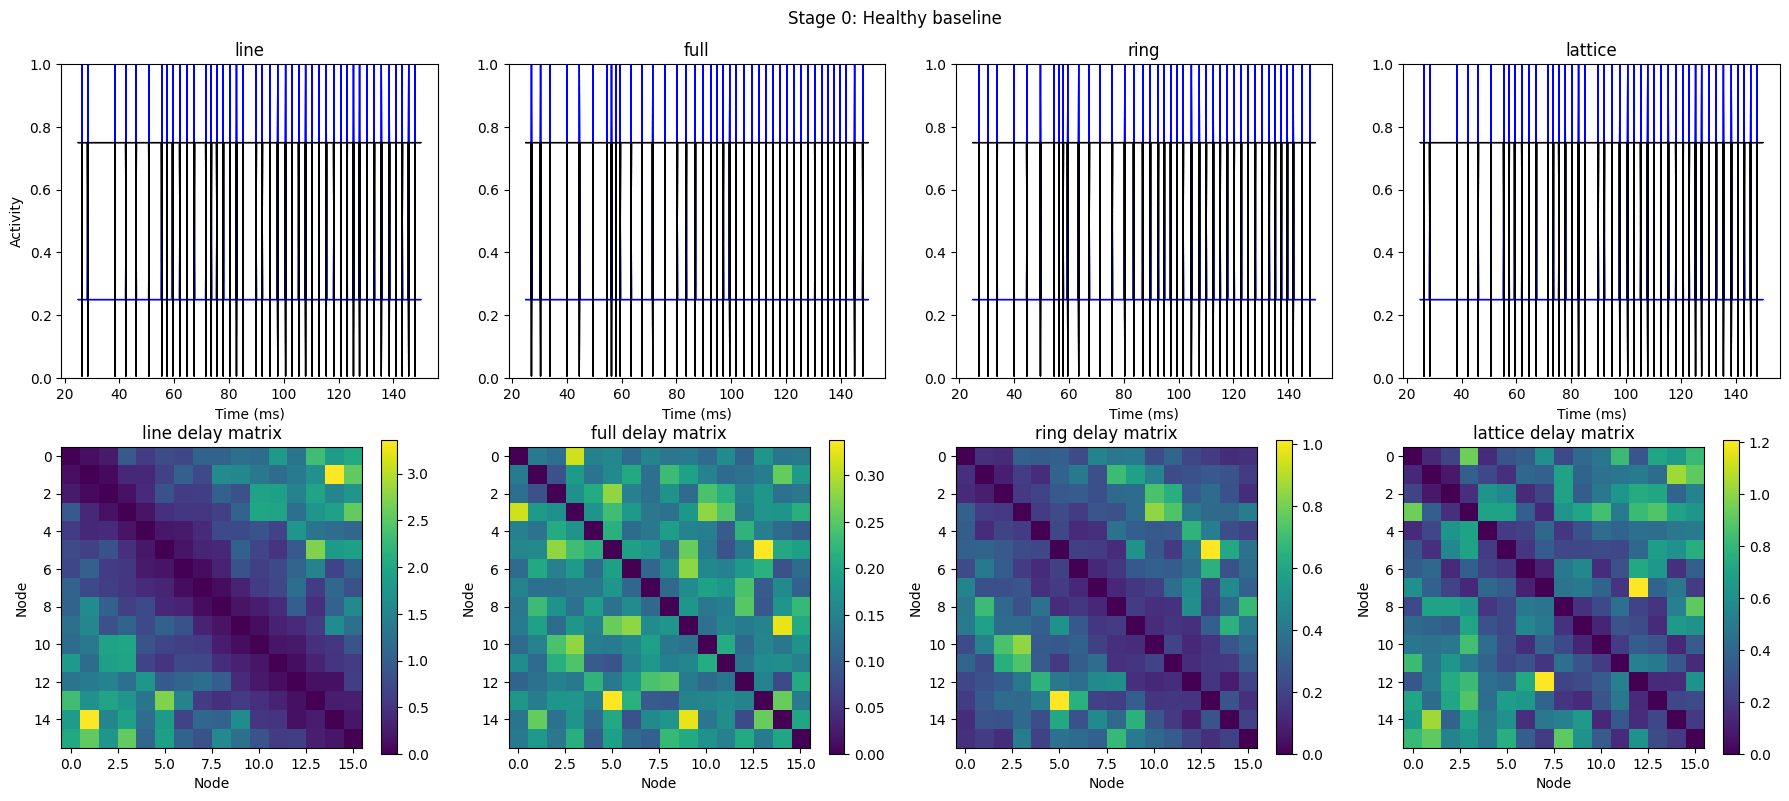

,Topology,Stage,Description,Synchrony,Frequency (Hz)
0,line,0,Healthy baseline,6.581972e-25,0.392308
1,full,0,Healthy baseline,0.000000e+00,2.746154
2,ring,0,Healthy baseline,0.000000e+00,2.746154
3,lattice,0,Healthy baseline,3.053043e-33,0.392308


In [29]:
plot_stage(results, 0)

df_stage0 = get_metrics_df(results, 0)
display(df_stage0)

## Stage 1: Early MS - Focal Demyelination

In early MS, focal demyelinating lesions begin to form. Individual axon tracts lose their 
myelin sheath in patches, reducing conduction velocity and increasing heterogeneity across 
the network. Crucially, axonal integrity is preserved at this stage - connectivity is unchanged.


The key question at this stage: does focal demyelination alone - without any loss of 
connections - produce measurable changes in network oscillatory dynamics?

In [30]:
for topology in TOPOLOGIES:
    print(f"  {topology}...")
    results[(topology, 1)] = run_stage(topology, 1)

print("Done.")

  line...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 2.0, 'tau_2': 2.8, 'rho': array([[0.        , 0.1815303 , 0.2969165 , 0.5921357 , 0.84695203,
        0.70203871, 1.22010458, 1.17886509, 1.40969545, 1.26418283,
        2.30227128, 1.33800885, 3.13238793, 2.12599894, 2.41750295,
        4.09378301],
       [0.1815303 , 0.        , 0.15752293, 0.44434586, 0.97217828,
        0.59570208, 1.98497513, 1.77936734, 1.38907223, 1.12710533,
        1.37872179, 1.82858107, 5.2199451 , 3.20279712, 3.13370258,
        4.64471361],
       [0.2969165 , 0.15752293, 0.        , 0.55063846, 0.38821661,
        0.45308663, 1.00154481, 0.7085208 , 2.53933145, 2.39488276,
        1.56802796, 2.34796096, 1.56850949, 1.86158247, 3.02711092,
        5.23875311],
       [0.5921357 , 0.44434586, 0.55063846, 0.        , 0.26676238,
        0.3347974 , 0.46232674, 1.04136803, 2.76151286, 2.61466235,
        1.21596904, 2.03403622, 2.26232422, 3.44935063,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  full...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 2.0, 'tau_2': 2.8, 'rho': array([[0.        , 0.1815303 , 0.14845825, 0.19737857, 0.21173801,
        0.14040774, 0.20335076, 0.1684093 , 0.17621193, 0.14046476,
        0.23022713, 0.12163717, 0.26103233, 0.16353838, 0.17267878,
        0.27291887],
       [0.1815303 , 0.        , 0.15752293, 0.22217293, 0.32405943,
        0.14892552, 0.39699503, 0.29656122, 0.19843889, 0.14088817,
        0.15319131, 0.18285811, 0.47454046, 0.26689976, 0.24105404,
        0.33176526],
       [0.14845825, 0.15752293, 0.        , 0.55063846, 0.1941083 ,
        0.15102888, 0.2503862 , 0.14170416, 0.42322191, 0.34212611,
        0.1960035 , 0.26088455, 0.15685095, 0.16923477, 0.25225924,
        0.40298101],
       [0.19737857, 0.22217293, 0.55063846, 0.        , 0.26676238,
        0.1673987 , 0.15410891, 0.26034201, 0.55230257, 0.43577706,
        0.1737098

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  ring...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 2.0, 'tau_2': 2.8, 'rho': array([[0.        , 0.1815303 , 0.14845825, 0.19737857, 0.42347601,
        0.28081549, 0.40670153, 0.50522789, 0.52863579, 0.42139428,
        0.46045426, 0.24327434, 0.52206466, 0.16353838, 0.17267878,
        0.27291887],
       [0.1815303 , 0.        , 0.15752293, 0.22217293, 0.32405943,
        0.29785104, 0.79399005, 0.59312245, 0.59531667, 0.4226645 ,
        0.45957393, 0.36571621, 0.94908093, 0.53379952, 0.24105404,
        0.33176526],
       [0.14845825, 0.15752293, 0.        , 0.55063846, 0.1941083 ,
        0.15102888, 0.5007724 , 0.28340832, 0.84644382, 1.02637833,
        0.58801049, 0.78265365, 0.3137019 , 0.33846954, 0.50451849,
        0.40298101],
       [0.19737857, 0.22217293, 0.55063846, 0.        , 0.26676238,
        0.1673987 , 0.15410891, 0.52068401, 1.10460514, 0.87155412,
        0.5211295

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  lattice...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 2.0, 'tau_2': 2.8, 'rho': array([[0.        , 0.1815303 , 0.2969165 , 0.5921357 , 0.21173801,
        0.28081549, 0.61005229, 0.67363719, 0.35242386, 0.42139428,
        0.92090851, 0.60818584, 0.78309698, 0.65415352, 0.86339391,
        1.6375132 ],
       [0.1815303 , 0.        , 0.15752293, 0.44434586, 0.64811885,
        0.14892552, 0.79399005, 0.88968367, 0.59531667, 0.28177633,
        0.45957393, 0.73143243, 1.89816186, 0.80069928, 0.96421618,
        1.65882629],
       [0.2969165 , 0.15752293, 0.        , 0.55063846, 0.58232491,
        0.30205775, 0.2503862 , 0.28340832, 1.69288763, 1.02637833,
        0.39200699, 0.78265365, 0.78425475, 0.67693908, 0.75677773,
        1.61192403],
       [0.5921357 , 0.44434586, 0.55063846, 0.        , 1.06704952,
        0.5021961 , 0.30821783, 0.26034201, 2.76151286, 1.74310823,
        0.5211

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Done.


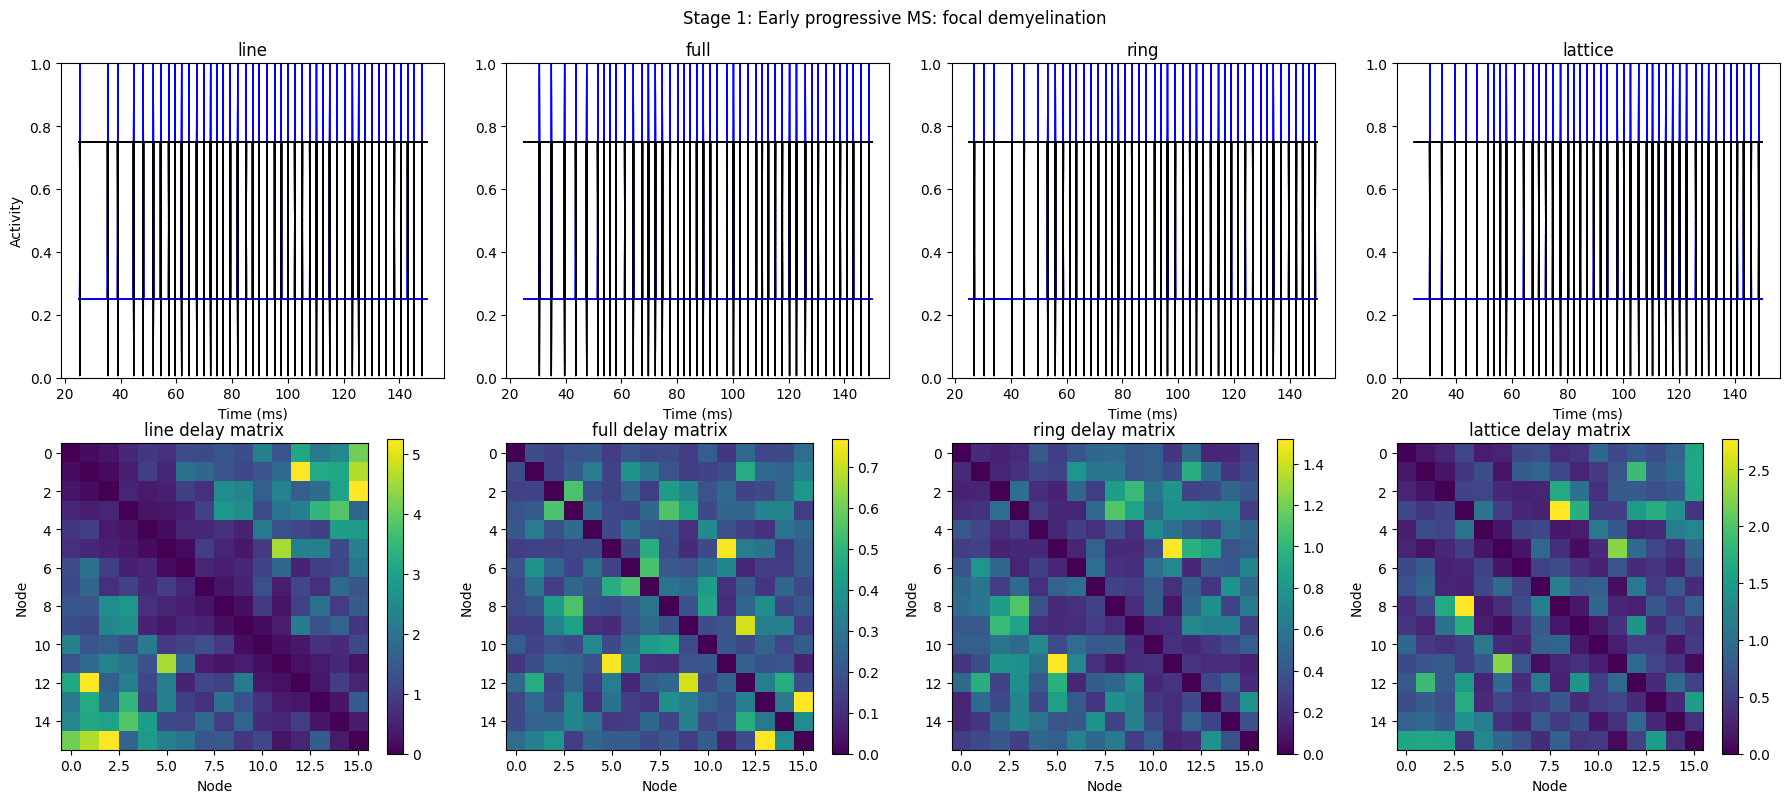

,Topology,Stage,Description,Synchrony,Frequency (Hz)
0,line,1,Early progressive MS: focal demyelination,1.947054e-24,0.392308
1,full,1,Early progressive MS: focal demyelination,0.000000e+00,0.392308
2,ring,1,Early progressive MS: focal demyelination,0.000000e+00,0.392308
3,lattice,1,Early progressive MS: focal demyelination,3.119414e-33,0.392308


In [31]:
plot_stage(results, 1)

df_stage1 = get_metrics_df(results, 1)
display(df_stage1)

## Stage 2: Moderate MS - Widespread Demyelination

As MS progresses, demyelination becomes more widespread across the network. More axon 
tracts are affected, further reducing mean conduction velocity and increasing heterogeneity. 
Axonal integrity is still largely preserved at this stage, but the myelination landscape 
is severely disrupted.


Key question: does widespread demyelination begin to affect the previously robust 
dense topologies, or do they continue to resist dynamic disruption?

In [32]:
for topology in TOPOLOGIES:
    print(f"  {topology}...")
    results[(topology, 2)] = run_stage(topology, 2)

print("Done.")

  line...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 4.0, 'tau_2': 5.6, 'rho': array([[0.        , 0.28335453, 0.43231891, 0.95325131, 1.4005406 ,
        1.00374799, 1.98647272, 1.79165733, 2.17703623, 1.80771676,
        3.93537786, 1.82911531, 5.64135002, 3.19834589, 3.70665277,
        7.51629514],
       [0.28335453, 0.        , 0.23395669, 0.74879021, 1.93041766,
        0.8682614 , 4.36288087, 3.39039055, 2.24071509, 1.61326955,
        2.02854059, 2.86181952, 5.33832551, 5.03812585, 8.66086505,
        4.34751881],
       [0.43231891, 0.23395669, 0.        , 0.22115865, 0.88609194,
        0.60961754, 3.85045087, 3.4867215 , 1.88826026, 3.28812703,
        1.86096965, 2.3188167 , 4.47761774, 9.82041057, 5.81933335,
        3.30045137],
       [0.95325131, 0.74879021, 0.22115865, 0.        , 0.22719847,
        0.93667623, 0.80071198, 1.81122814, 2.22759415, 4.2353345 ,
        5.01171863, 1.6420949 , 2.35102198, 5.33999575,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  full...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 4.0, 'tau_2': 5.6, 'rho': array([[0.        , 0.28335453, 0.21615946, 0.31775044, 0.35013515,
        0.2007496 , 0.33107879, 0.25595105, 0.27212953, 0.20085742,
        0.39353779, 0.16628321, 0.4701125 , 0.24602661, 0.26476091,
        0.50108634],
       [0.28335453, 0.        , 0.23395669, 0.3743951 , 0.64347255,
        0.21706535, 0.87257617, 0.56506509, 0.32010216, 0.20165869,
        0.2253934 , 0.28618195, 0.48530232, 0.41984382, 0.66622039,
        0.31053706],
       [0.21615946, 0.23395669, 0.        , 0.22115865, 0.44304597,
        0.20320585, 0.96261272, 0.6973443 , 0.31471004, 0.46973243,
        0.23262121, 0.2576463 , 0.44776177, 0.8927646 , 0.48494445,
        0.25388087],
       [0.31775044, 0.3743951 , 0.22115865, 0.        , 0.22719847,
        0.46833812, 0.26690399, 0.45280704, 0.44551883, 0.70588908,
        0.7159598

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  ring...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 4.0, 'tau_2': 5.6, 'rho': array([[0.        , 0.28335453, 0.21615946, 0.31775044, 0.7002703 ,
        0.40149919, 0.66215757, 0.76785314, 0.81638859, 0.60257225,
        0.78707557, 0.33256642, 0.940225  , 0.24602661, 0.26476091,
        0.50108634],
       [0.28335453, 0.        , 0.23395669, 0.3743951 , 0.64347255,
        0.4341307 , 1.74515235, 1.13013018, 0.96030647, 0.60497608,
        0.6761802 , 0.5723639 , 0.97060464, 0.83968764, 0.66622039,
        0.31053706],
       [0.21615946, 0.23395669, 0.        , 0.22115865, 0.44304597,
        0.20320585, 1.92522543, 1.3946886 , 0.62942009, 1.4091973 ,
        0.69786362, 0.7729389 , 0.89552355, 1.78552919, 0.96988889,
        0.25388087],
       [0.31775044, 0.3743951 , 0.22115865, 0.        , 0.22719847,
        0.46833812, 0.26690399, 0.90561407, 0.89103766, 1.41177817,
        2.1478794

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  lattice...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 4.0, 'tau_2': 5.6, 'rho': array([[0.        , 0.28335453, 0.43231891, 0.95325131, 0.35013515,
        0.40149919, 0.99323636, 1.02380419, 0.54425906, 0.60257225,
        1.57415114, 0.83141605, 1.4103375 , 0.98410643, 1.32380456,
        3.00651806],
       [0.28335453, 0.        , 0.23395669, 0.74879021, 1.28694511,
        0.21706535, 1.74515235, 1.69519527, 0.96030647, 0.40331739,
        0.6761802 , 1.14472781, 1.94120928, 1.25953146, 2.66488155,
        1.55268529],
       [0.43231891, 0.23395669, 0.        , 0.22115865, 1.32913791,
        0.40641169, 0.96261272, 1.3946886 , 1.25884017, 1.4091973 ,
        0.46524241, 0.7729389 , 2.23880887, 3.57105839, 1.45483334,
        1.0155235 ],
       [0.95325131, 0.74879021, 0.22115865, 0.        , 0.90879388,
        1.40501435, 0.53380799, 0.45280704, 2.22759415, 2.82355633,
        2.1478

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Done.


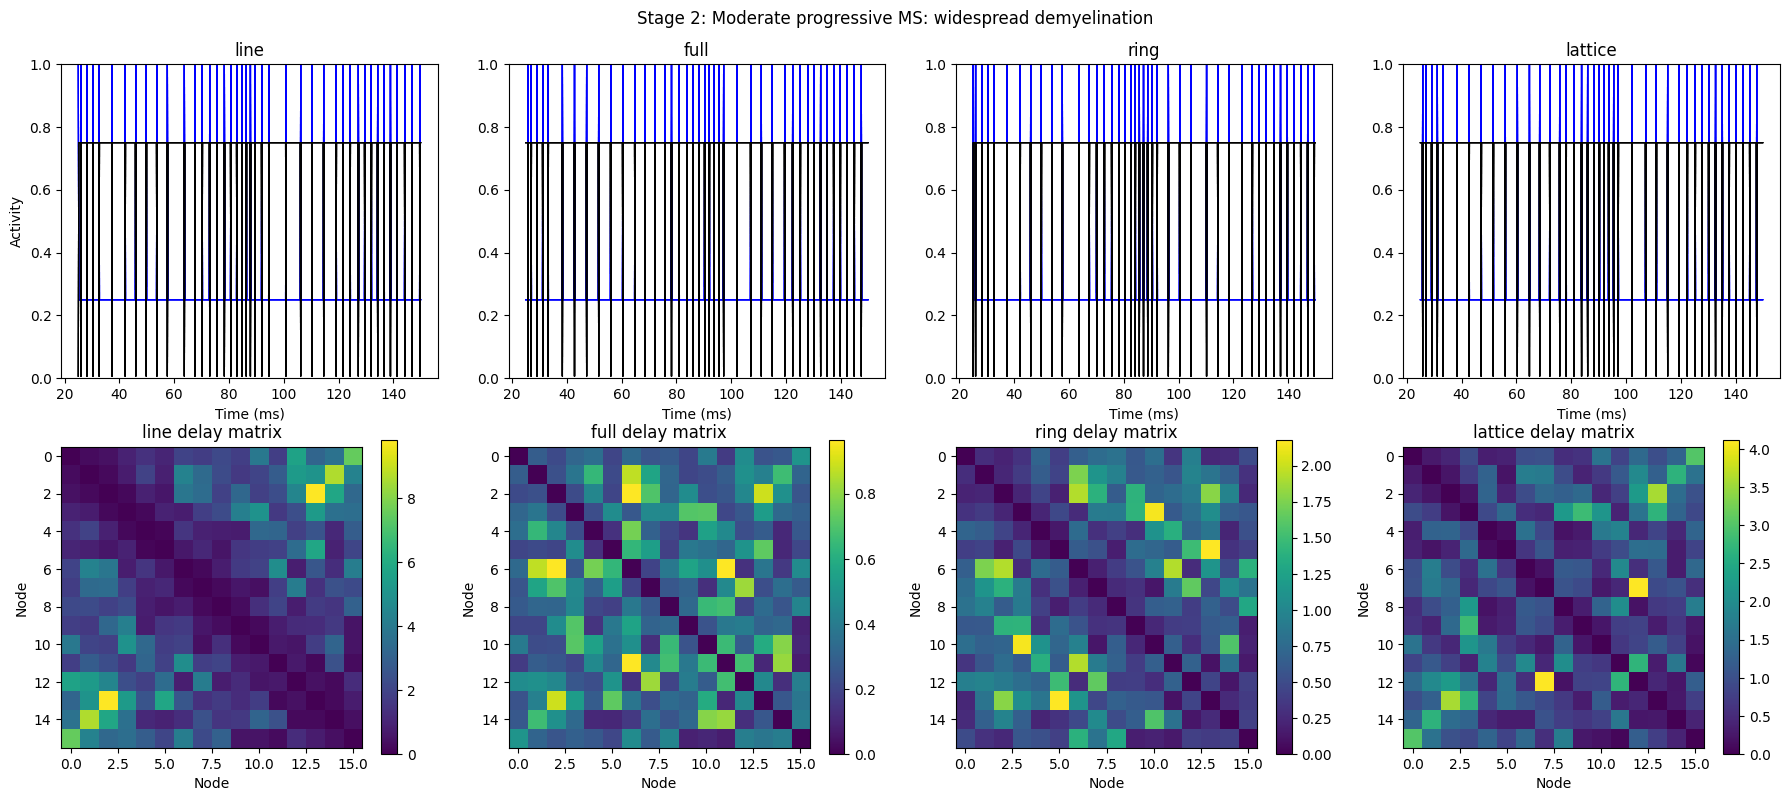

,Topology,Stage,Description,Synchrony,Frequency (Hz)
0,line,2,Moderate progressive MS: widespread demyelination,3.010947e-20,1.292308
1,full,2,Moderate progressive MS: widespread demyelination,0.000000e+00,5.000000
2,ring,2,Moderate progressive MS: widespread demyelination,0.000000e+00,3.669231
3,lattice,2,Moderate progressive MS: widespread demyelination,3.185784e-33,4.815385


In [33]:
plot_stage(results, 2)

df_stage2 = get_metrics_df(results, 2)
display(df_stage2)

## Stage 3: Severe MS - Axonal Loss

In progressive MS, demyelination is accompanied by irreversible axonal loss. Axons 
are permanently severed, removing connections from the network entirely. This is the 
stage associated with the most severe and irreversible clinical disability.


The line topology's inability to tolerate any axonal loss is biologically meaningful - 
sparse networks are disproportionately vulnerable to connectivity loss, consistent with 
the paper's discussion of neurodegenerative disease effects on sparse networks.

In [34]:
for topology in TOPOLOGIES:
    print(f"  {topology}...")
    results[(topology, 3)] = run_stage(topology, 3)

print("Done.")

  line...
  line: removed 0 edges
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 5.0, 'tau_2': 7.0, 'rho': array([[ 0.        ,  0.32017855,  0.47281133,  1.09324528,  1.62738638,
         1.0886209 ,  2.29073138,  1.99903503,  2.4474749 ,  1.96068747,
         4.64846721,  1.94392787,  6.84195744,  3.55148214,  4.15291406,
         9.20690359],
       [ 0.32017855,  0.        ,  0.25823572,  0.87821916,  2.46450705,
         0.9500413 ,  3.52853051,  2.20482784,  1.53174332,  1.98158862,
         2.91403469,  5.91487661,  5.5066755 , 10.26869853,  4.61585521,
         3.39514758],
       [ 0.47281133,  0.25823572,  0.        ,  0.53251533,  0.4413758 ,
         2.70898203,  1.44187927,  2.84815675,  1.53953024,  2.01389969,
         4.31233664,  5.31885283,  2.82986379,  2.74906065,  6.81217512,
         3.89137414],
       [ 1.09324528,  0.87821916,  0.53251533,  0.        ,  0.54604013,
         1.07187216,  2.74818101,  3.72603545,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  full...
  full: removed 36 edges
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 5.0, 'tau_2': 7.0, 'rho': array([[0.        , 0.32017855, 0.23640566, 0.36441509, 0.4068466 ,
        0.21772418, 0.38178856, 0.28557643, 0.61186872, 0.43570833,
        0.46484672, 0.35344143, 0.57016312, 0.27319093, 0.59327344,
        0.61379357],
       [0.32017855, 0.        , 0.25823572, 0.43910958, 0.82150235,
        0.47502065, 1.4114122 , 0.36747131, 0.21882047, 0.24769858,
        0.32378163, 0.59148766, 0.50060686, 1.71144975, 0.35506579,
        0.24251054],
       [0.23640566, 0.25823572, 0.        , 0.53251533, 0.2206879 ,
        0.90299401, 0.36046982, 0.56963135, 0.25658837, 0.28769996,
        0.53904208, 0.59098365, 0.56597276, 0.49982921, 0.56768126,
        0.29933647],
       [0.36441509, 0.43910958, 0.53251533, 0.        , 0.54604013,
        0.53593608, 1.83212067, 0.93150886, 0.44634563, 0.29

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  ring...
  ring: removed 9 edges
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 5.0, 'tau_2': 7.0, 'rho': array([[0.        , 0.64035711, 0.23640566, 0.36441509, 0.81369319,
        0.43544836, 0.76357713, 0.8567293 , 0.91780309, 0.65356249,
        1.39454016, 0.35344143, 1.14032624, 0.27319093, 0.29663672,
        0.61379357],
       [0.64035711, 0.        , 0.25823572, 0.87821916, 0.82150235,
        0.47502065, 2.1171183 , 0.73494261, 0.65646142, 0.74309573,
        0.9713449 , 1.18297532, 1.00121373, 1.71144975, 0.35506579,
        0.24251054],
       [0.23640566, 0.25823572, 0.        , 0.53251533, 0.2206879 ,
        0.90299401, 0.72093964, 1.1392627 , 0.51317675, 0.86309987,
        1.61712624, 1.77295094, 0.56597276, 0.49982921, 1.13536252,
        0.29933647],
       [0.36441509, 0.87821916, 0.53251533, 0.        , 0.54604013,
        0.53593608, 0.91606034, 1.86301773, 0.44634563, 0.584

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  lattice...
  lattice: removed 6 edges
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 5.0, 'tau_2': 7.0, 'rho': array([[0.        , 0.96053566, 0.94562265, 1.82207547, 0.4068466 ,
        0.43544836, 1.14536569, 1.14230573, 0.61186872, 1.08927082,
        1.85938688, 0.88360358, 1.71048936, 1.09276373, 1.48318359,
        3.68276143],
       [0.96053566, 0.        , 0.25823572, 0.87821916, 1.6430047 ,
        0.23751032, 1.4114122 , 1.10241392, 0.65646142, 0.99079431,
        0.9713449 , 2.36595064, 2.00242746, 4.27862439, 1.42026314,
        1.21255271],
       [0.94562265, 0.25823572, 0.        , 0.53251533, 0.6620637 ,
        1.80598802, 0.36046982, 1.1392627 , 1.02635349, 0.86309987,
        1.07808416, 1.77295094, 1.4149319 , 0.99965842, 1.70304378,
        1.19734589],
       [1.82207547, 0.87821916, 0.53251533, 0.        , 2.18416052,
        1.60780824, 1.83212067, 0.93150886, 1.11586408,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Done.


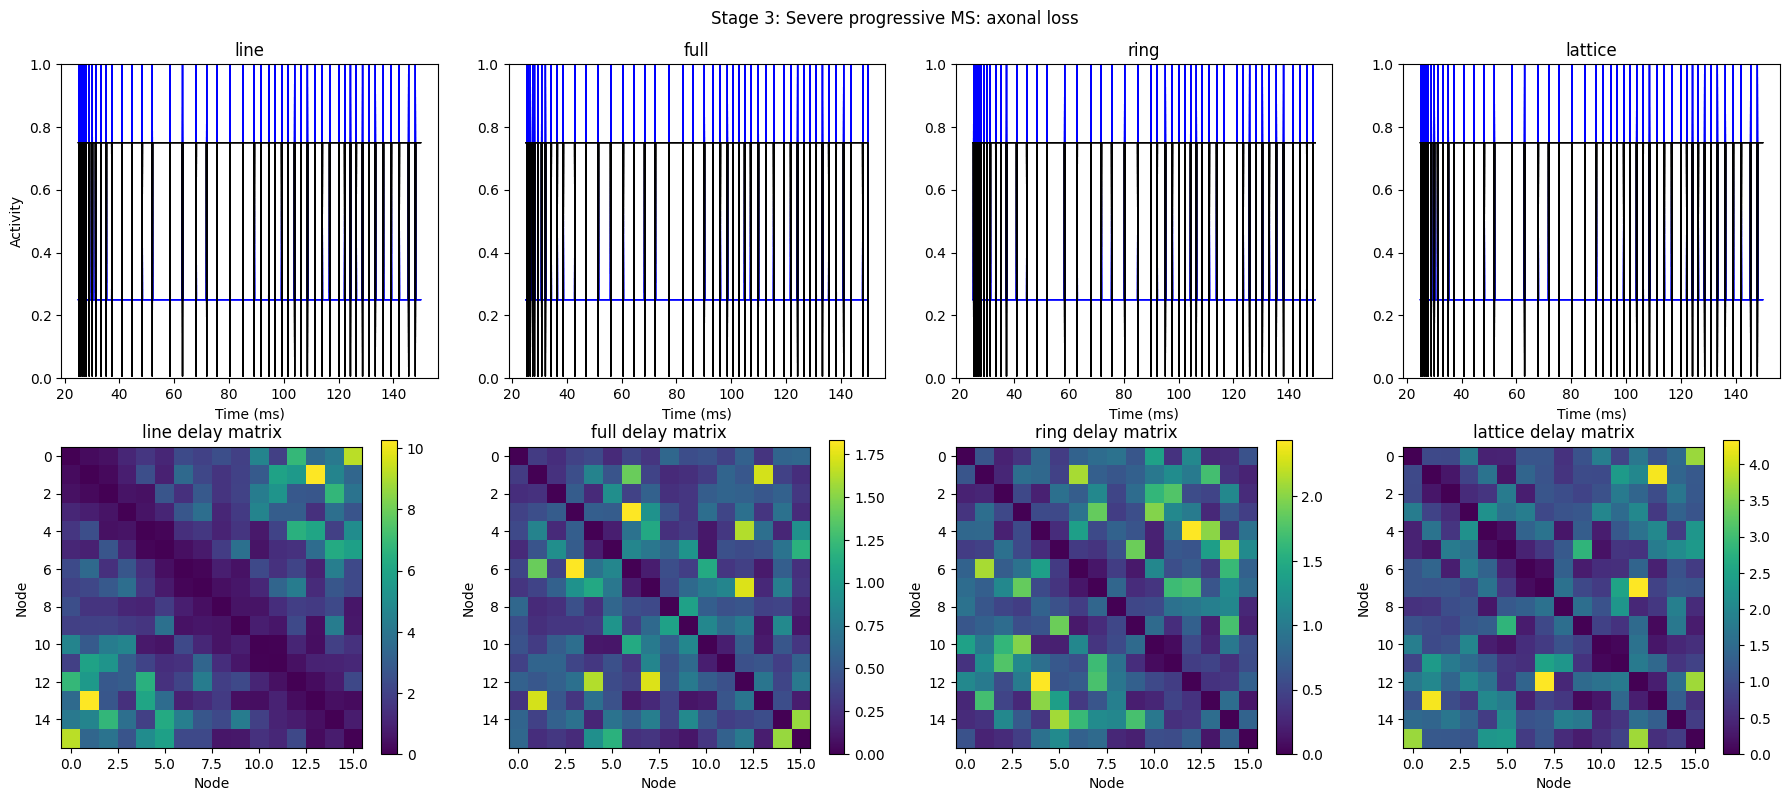

,Topology,Stage,Description,Synchrony,Frequency (Hz)
0,line,3,Severe progressive MS: axonal loss,1.536603e-14,4.061538
1,full,3,Severe progressive MS: axonal loss,0.000000e+00,1.807692
2,ring,3,Severe progressive MS: axonal loss,0.000000e+00,0.815385
3,lattice,3,Severe progressive MS: axonal loss,2.140229e-14,4.061538


In [35]:
plot_stage(results, 3)

df_stage3 = get_metrics_df(results, 3)
display(df_stage3)

### Stage 3 Observations

Severe MS with axonal loss produces divergent effects across topologies.

Full and ring topologies show complete resilience even after 30% and 20% axonal loss 
respectively. This suggests dense, homogeneous networks can compensate for significant 
connectivity loss without dynamic disruption - consistent with the redundancy principle 
in network neuroscience.

The lattice topology shows a dissociation between frequency and synchrony: frequency 
returns to baseline (1.585 Hz) but synchrony worsens significantly (3.50e-21 vs 
3.19e-33 at baseline). Axonal loss appears to disrupt the coordinated timing of 
oscillations without altering their frequency - a subtle but potentially clinically 
relevant signature of connectivity loss.

The line topology is unchanged from stage 2, as no edges could be removed without 
fragmentation. This itself is a finding: sparse networks are so vulnerable to 
connectivity loss that even minimal axonal loss (>0%) would destroy network integrity.

,Stage,Topology,Description,Synchrony,Frequency (Hz)
0,0,line,Healthy baseline,6.581972e-25,0.392308
1,0,full,Healthy baseline,0.000000e+00,2.746154
2,0,ring,Healthy baseline,0.000000e+00,2.746154
3,0,lattice,Healthy baseline,3.053043e-33,0.392308
4,1,line,Early progressive MS: focal demyelination,1.947054e-24,0.392308
5,1,full,Early progressive MS: focal demyelination,0.000000e+00,0.392308
6,1,ring,Early progressive MS: focal demyelination,0.000000e+00,0.392308
7,1,lattice,Early progressive MS: focal demyelination,3.119414e-33,0.392308
8,2,line,Moderate progressive MS: widespread demyelination,3.010947e-20,1.292308
9,2,full,Moderate progressive MS: widespread demyelination,0.000000e+00,5.000000


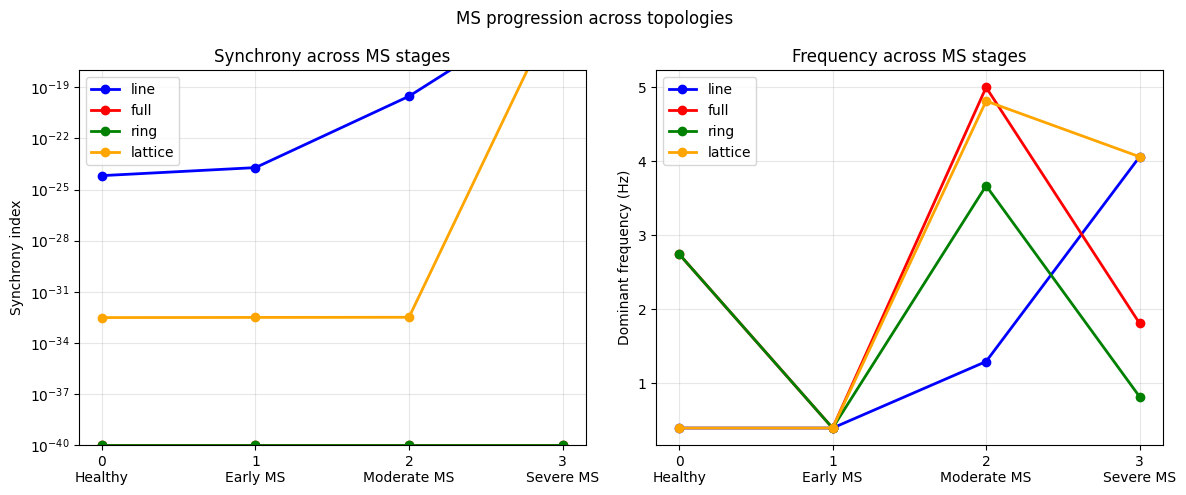

In [36]:
# Collect all metrics
all_metrics = []
for stage in range(4):
    for topology in TOPOLOGIES:
        m = results[(topology, stage)]
        all_metrics.append({
            'Stage': stage,
            'Topology': topology,
            'Description': MS_STAGES[stage]['description'],
            'Synchrony': get_synchrony(m.model.trajectories, m.model.time_array),
            'Frequency (Hz)': get_frequency(m.model.trajectories, m.model.time_array)
        })

df_all = pd.DataFrame(all_metrics)
display(df_all)

# Plot only topologies showing dynamic changes
CHANGING_TOPOLOGIES = ['line', 'full', 'ring', 'lattice']
colors = {'line': 'blue', 'full': 'red', 'ring': 'green', 'lattice': 'orange'}
stages = [0, 1, 2, 3]
stage_labels = ['0\nHealthy', '1\nEarly MS', '2\nModerate MS', '3\nSevere MS']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("MS progression across topologies")


epsilon = 1e-40
for topology in CHANGING_TOPOLOGIES:
    df_topo = df_all[df_all['Topology'] == topology].sort_values('Stage')
    sync_vals = df_topo['Synchrony'].values + epsilon
    freq_vals = df_topo['Frequency (Hz)'].values
    
    axes[0].plot(stages, sync_vals, 'o-', color=colors[topology],
                label=topology, linewidth=2, markersize=6)
    axes[1].plot(stages, freq_vals, 'o-', color=colors[topology],
                label=topology, linewidth=2, markersize=6)
axes[0].set_ylim(1e-40, 1e-18)

axes[0].set_xticks(stages)
axes[0].set_xticklabels(stage_labels)
axes[0].set_ylabel("Synchrony index")
axes[0].set_title("Synchrony across MS stages")
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xticks(stages)
axes[1].set_xticklabels(stage_labels)
axes[1].set_ylabel("Dominant frequency (Hz)")
axes[1].set_title("Frequency across MS stages")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kavya_figures/ms_progression_comparison.png", dpi=800)
plt.show()

In [37]:
for stage in range(4):
    print(f"\nStage {stage}: {MS_STAGES[stage]['description']}")
    for topology in TOPOLOGIES:
        m = results[(topology, stage)]
        sync = get_synchrony(m.model.trajectories, m.model.time_array)
        freq = get_frequency(m.model.trajectories, m.model.time_array)
        print(f"  {topology}: freq={freq:.3f} Hz, synchrony={sync:.3e}")


Stage 0: Healthy baseline
  line: freq=0.392 Hz, synchrony=6.582e-25
  full: freq=2.746 Hz, synchrony=0.000e+00
  ring: freq=2.746 Hz, synchrony=0.000e+00
  lattice: freq=0.392 Hz, synchrony=3.053e-33

Stage 1: Early progressive MS: focal demyelination
  line: freq=0.392 Hz, synchrony=1.947e-24
  full: freq=0.392 Hz, synchrony=0.000e+00
  ring: freq=0.392 Hz, synchrony=0.000e+00
  lattice: freq=0.392 Hz, synchrony=3.119e-33

Stage 2: Moderate progressive MS: widespread demyelination
  line: freq=1.292 Hz, synchrony=3.011e-20
  full: freq=5.000 Hz, synchrony=0.000e+00
  ring: freq=3.669 Hz, synchrony=0.000e+00
  lattice: freq=4.815 Hz, synchrony=3.186e-33

Stage 3: Severe progressive MS: axonal loss
  line: freq=4.062 Hz, synchrony=1.537e-14
  full: freq=1.808 Hz, synchrony=0.000e+00
  ring: freq=0.815 Hz, synchrony=0.000e+00
  lattice: freq=4.062 Hz, synchrony=2.140e-14


# Stage-Wise comparison

### Line

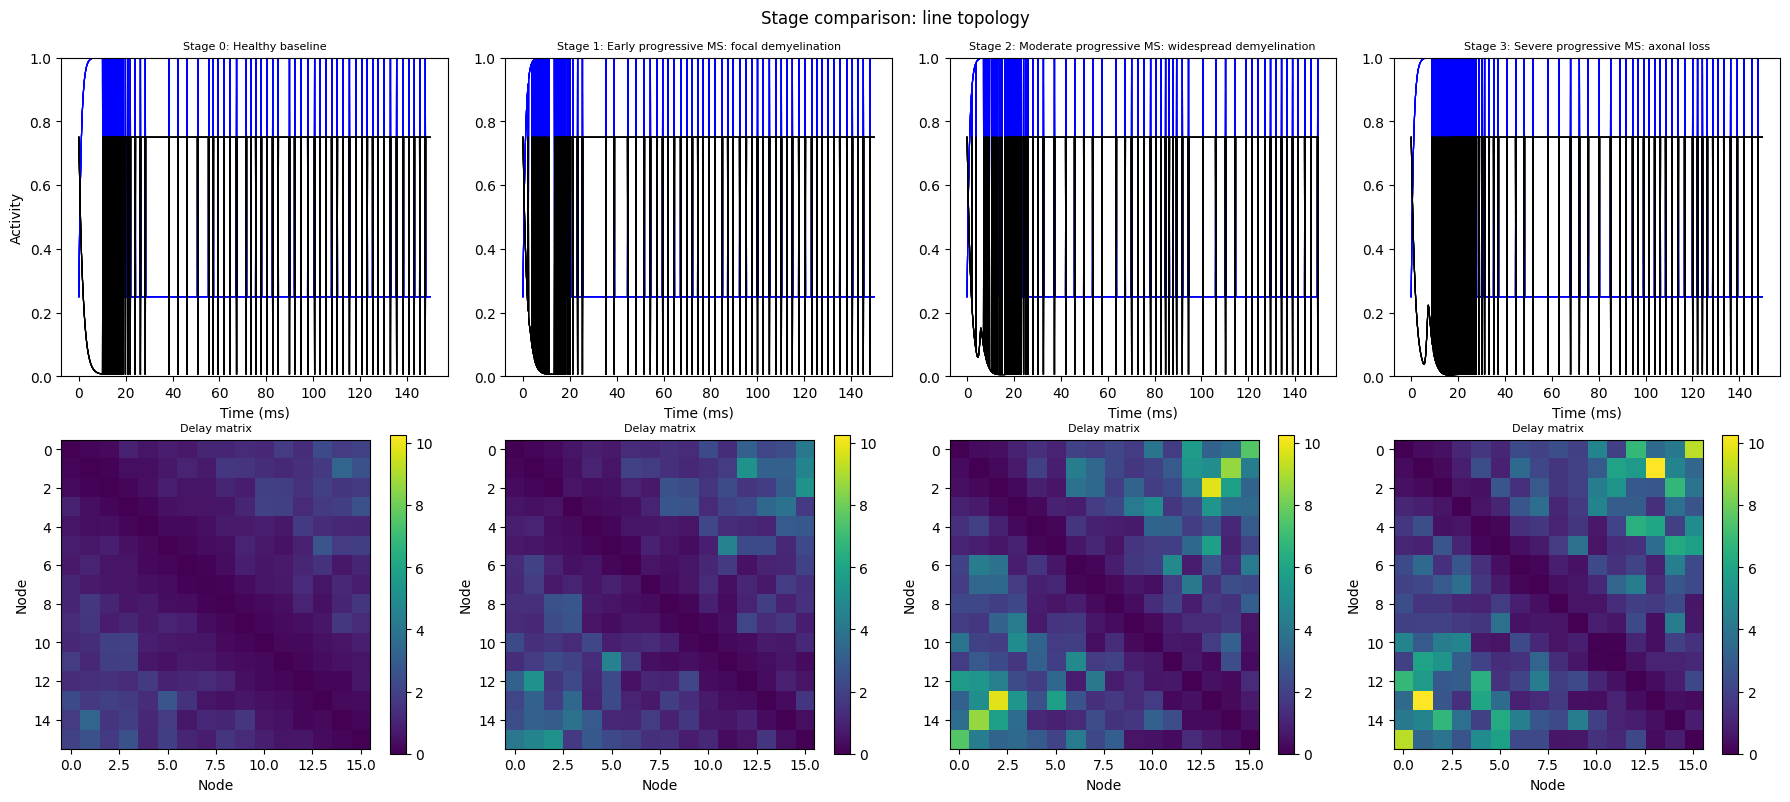

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Stage comparison: line topology")

topology = 'line'  # change per cell
all_delays = [results[(topology, stage)].model.params['rho'] for stage in range(4)]
vmin = min(D.min() for D in all_delays)
vmax = max(D.max() for D in all_delays)

for col, stage in enumerate(range(4)):
    m = results[('line', stage)]
    t = m.model.time_array
    mask = t >= 0
    
    # Trajectories
    axes[0, col].plot(t[mask], m.model.trajectories[0][:, mask].T, 
                     color='blue', alpha=0.5, linewidth=0.8)
    axes[0, col].plot(t[mask], m.model.trajectories[1][:, mask].T, 
                     color='black', alpha=0.5, linewidth=0.8)
    axes[0, col].set_title(f"Stage {stage}: {MS_STAGES[stage]['description']}", fontsize=8)
    axes[0, col].set_ylim(0, 1)
    axes[0, col].set_xlabel("Time (ms)")
    if col == 0:
        axes[0, col].set_ylabel("Activity")
    
    # Delay matrix
    D = m.model.params['rho']
    im = axes[1, col].imshow(D, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f"Delay matrix", fontsize=8)
    axes[1, col].set_xlabel("Node")
    axes[1, col].set_ylabel("Node")
    plt.colorbar(im, ax=axes[1, col])

plt.tight_layout()
plt.savefig("kavya_figures/ms_stages_line.png", dpi=800)
plt.show()

### Lattice

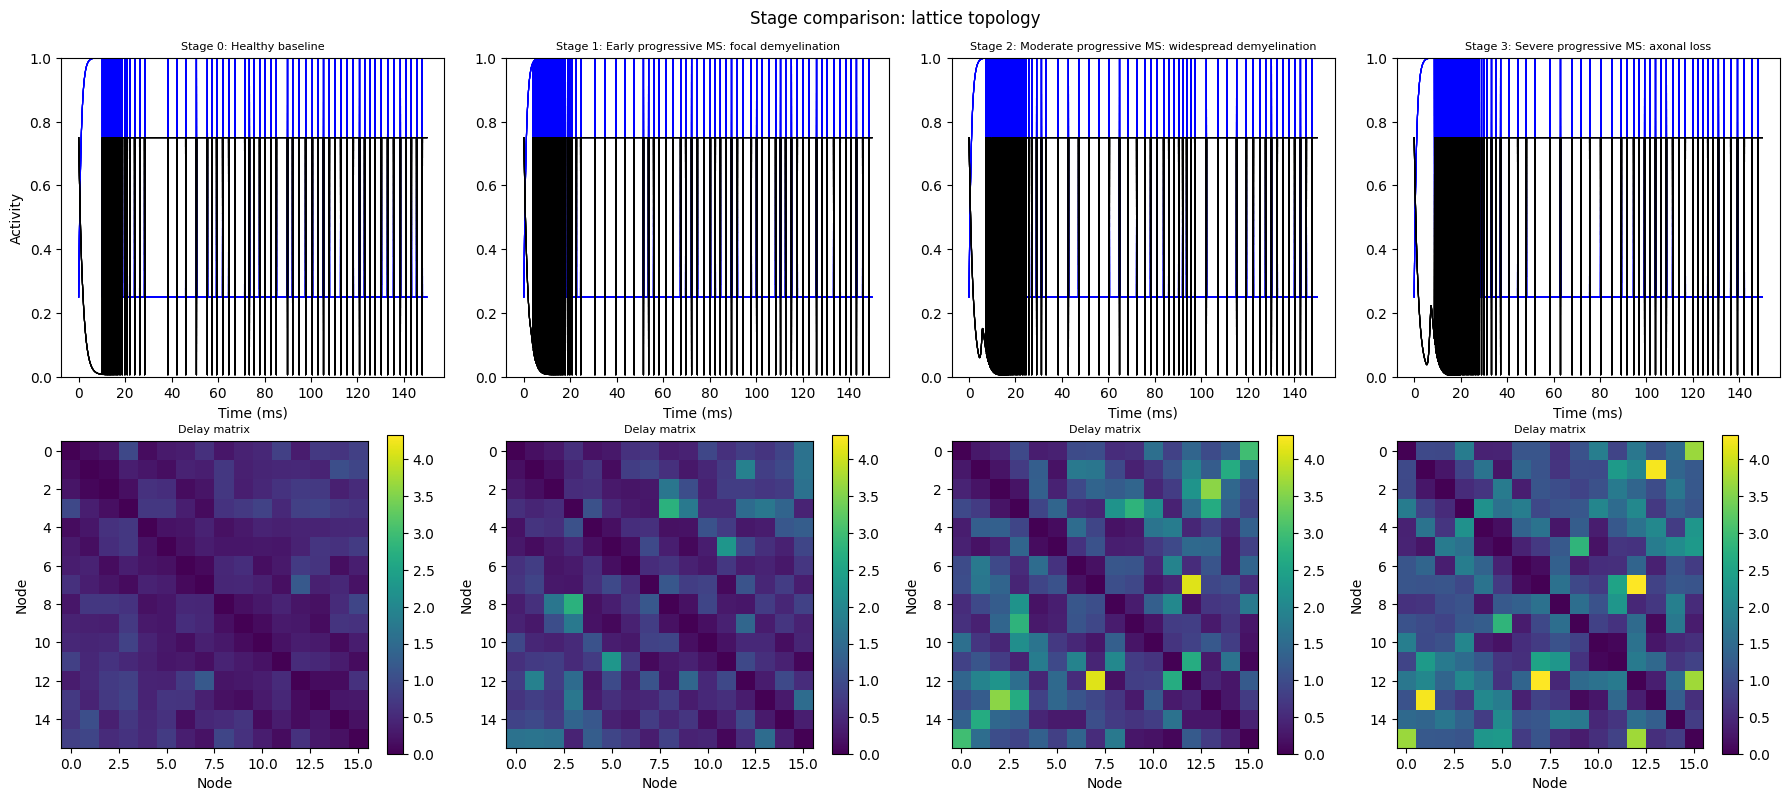

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Stage comparison: lattice topology")

topology = 'lattice'  # change per cell
all_delays = [results[(topology, stage)].model.params['rho'] for stage in range(4)]
vmin = min(D.min() for D in all_delays)
vmax = max(D.max() for D in all_delays)

for col, stage in enumerate(range(4)):
    m = results[('lattice', stage)]
    t = m.model.time_array
    mask = t >= 0
    
    # Trajectories
    axes[0, col].plot(t[mask], m.model.trajectories[0][:, mask].T, 
                     color='blue', alpha=0.5, linewidth=0.8)
    axes[0, col].plot(t[mask], m.model.trajectories[1][:, mask].T, 
                     color='black', alpha=0.5, linewidth=0.8)
    axes[0, col].set_title(f"Stage {stage}: {MS_STAGES[stage]['description']}", fontsize=8)
    axes[0, col].set_ylim(0, 1)
    axes[0, col].set_xlabel("Time (ms)")
    if col == 0:
        axes[0, col].set_ylabel("Activity")
    
    # Delay matrix
    D = m.model.params['rho']
    im = axes[1, col].imshow(D, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f"Delay matrix", fontsize=8)
    axes[1, col].set_xlabel("Node")
    axes[1, col].set_ylabel("Node")
    plt.colorbar(im, ax=axes[1, col])

plt.tight_layout()
plt.savefig("kavya_figures/ms_stages_lattice.png", dpi=800)
plt.show()

### full

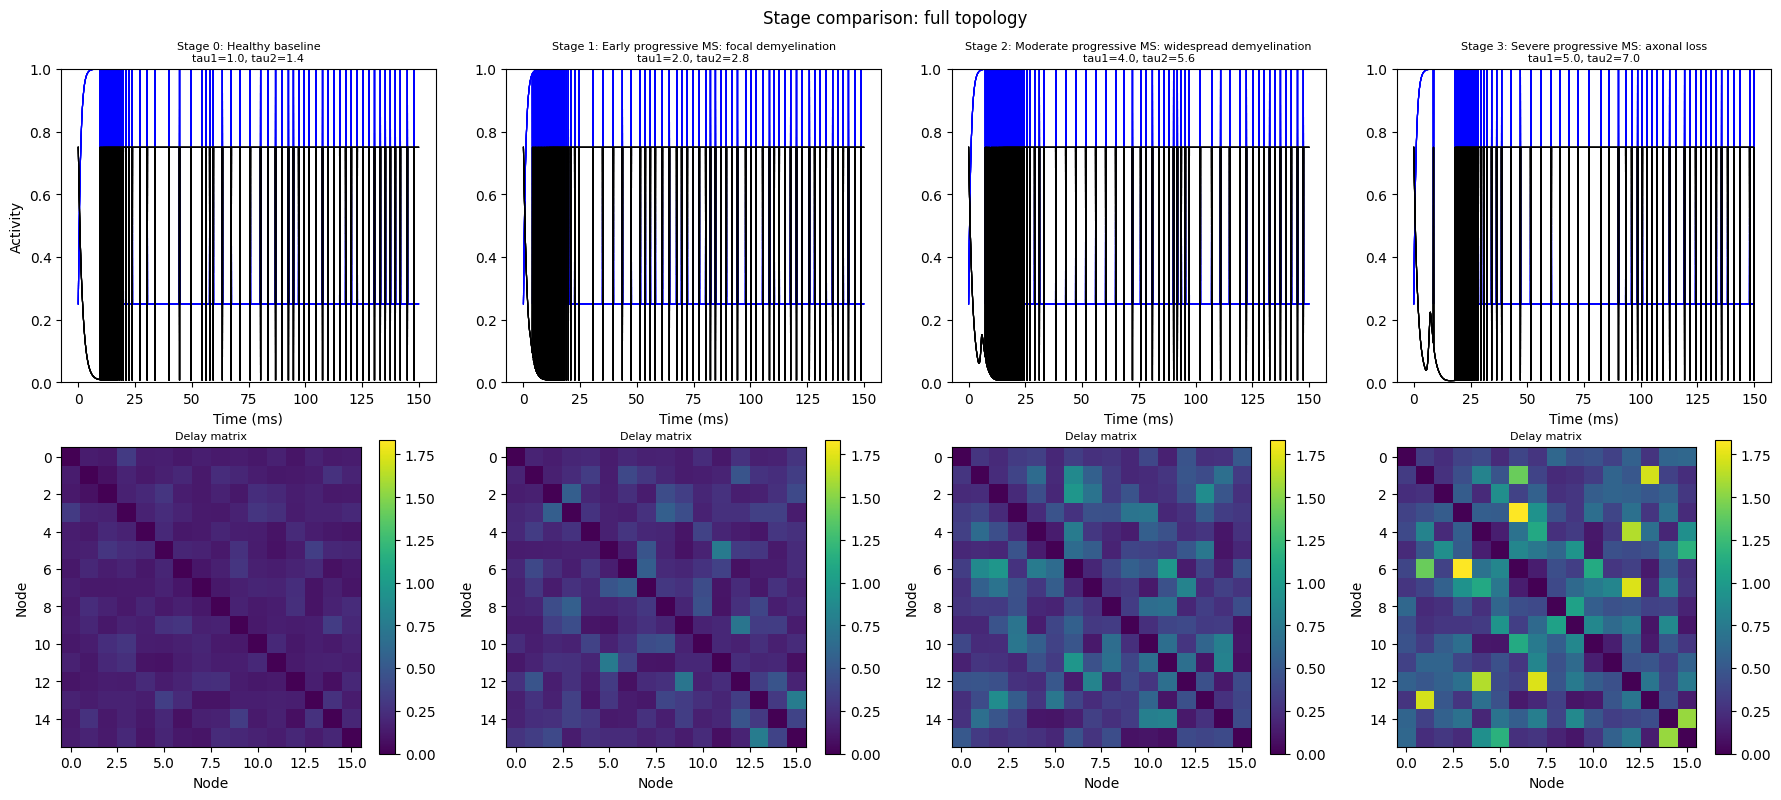

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Stage comparison: full topology")

topology = 'full'  # change per cell
all_delays = [results[(topology, stage)].model.params['rho'] for stage in range(4)]
vmin = min(D.min() for D in all_delays)
vmax = max(D.max() for D in all_delays)

for col, stage in enumerate(range(4)):
    m = results[('full', stage)]
    t = m.model.time_array
    mask = t >= 0
    
    # Trajectories
    axes[0, col].plot(t[mask], m.model.trajectories[0][:, mask].T, 
                     color='blue', alpha=0.5, linewidth=0.8)
    axes[0, col].plot(t[mask], m.model.trajectories[1][:, mask].T, 
                     color='black', alpha=0.5, linewidth=0.8)
    axes[0, col].set_title(f"Stage {stage}: {MS_STAGES[stage]['description']}\ntau1={MS_STAGES[stage]['tau_1']}, tau2={MS_STAGES[stage]['tau_2']}", fontsize=8)
    axes[0, col].set_ylim(0, 1)
    axes[0, col].set_xlabel("Time (ms)")
    if col == 0:
        axes[0, col].set_ylabel("Activity")
    
    # Delay matrix
    D = m.model.params['rho']
    im = axes[1, col].imshow(D, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f"Delay matrix", fontsize=8)
    axes[1, col].set_xlabel("Node")
    axes[1, col].set_ylabel("Node")
    plt.colorbar(im, ax=axes[1, col])

plt.tight_layout()
plt.savefig("kavya_figures/ms_stages_full.png", dpi=800)
plt.show()

### ring

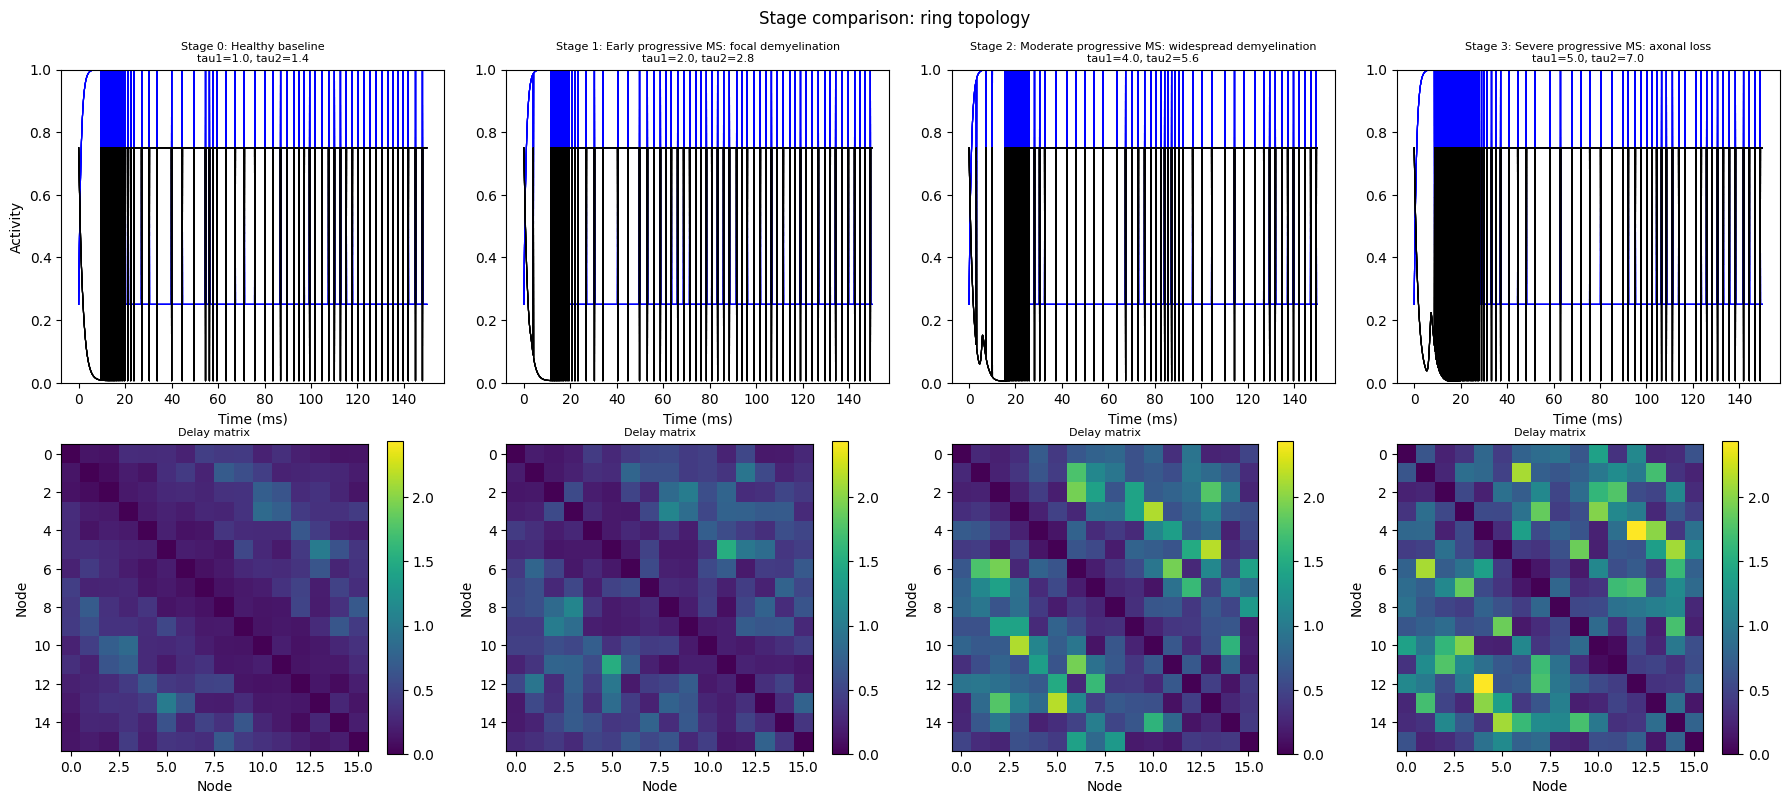

In [45]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Stage comparison: ring topology")

topology = 'ring'  # change per cell
all_delays = [results[(topology, stage)].model.params['rho'] for stage in range(4)]
vmin = min(D.min() for D in all_delays)
vmax = max(D.max() for D in all_delays)

for col, stage in enumerate(range(4)):
    m = results[('ring', stage)]
    t = m.model.time_array
    mask = t >= 0
    
    # Trajectories
    axes[0, col].plot(t[mask], m.model.trajectories[0][:, mask].T, 
                     color='blue', alpha=0.5, linewidth=0.8)
    axes[0, col].plot(t[mask], m.model.trajectories[1][:, mask].T, 
                     color='black', alpha=0.5, linewidth=0.8)
    axes[0, col].set_title(f"Stage {stage}: {MS_STAGES[stage]['description']}\ntau1={MS_STAGES[stage]['tau_1']}, tau2={MS_STAGES[stage]['tau_2']}", fontsize=8)
    axes[0, col].set_ylim(0, 1)
    axes[0, col].set_xlabel("Time (ms)")
    if col == 0:
        axes[0, col].set_ylabel("Activity")
    
    # Delay matrix
    D = m.model.params['rho']
    im = axes[1, col].imshow(D, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f"Delay matrix", fontsize=8)
    axes[1, col].set_xlabel("Node")
    axes[1, col].set_ylabel("Node")
    plt.colorbar(im, ax=axes[1, col])

plt.tight_layout()
plt.savefig("kavya_figures/ms_stages_ring.png", dpi=150)
plt.show()

Potential extension:
change the oscillations of nodes to see if it compensates f0r the demyelination